# Experiment 2 — X Chromosome: Fine-Grained Sub-Population Classification

**Goal:**
- **Supervised:** Predict sub-population label (26 specific populations e.g. YRI, CEU, CHB…) from X chromosome genotype data.
- **Unsupervised:** Apply K-Means (k=26) to discover sub-population clusters without labels.

**Key difference from Exp 1:** Uses `pop` column (26 sub-populations) instead of `super_pop` (5 groups).

**Pipeline:**
1. Stream all 3.4M QC-passed X chromosome variants — Gram-matrix PCA on MPS GPU
2. Sex-aware genotype encoding
3. Supervised classifiers: Logistic Regression, SVM, Random Forest, Decision Tree, KNN
4. K-Means clustering (k=26) with ARI & NMI evaluation

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import torch
import time

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE     = "/Users/aaditya/VS Code/1000 genome project"
CSV_PATH = f"{BASE}/Data/chrX_full.csv"
QC_PATH  = f"{BASE}/Code/chrX_variant_summary_qc.csv"
PANEL    = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR  = f"{BASE}/Output /"

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f"Using device : {device}")
print("Imports OK")

Using device : mps
Imports OK


## 1. Load Panel, QC Variant List & Detect Sample Columns

In [7]:
# ── Population panel ───────────────────────────────────────────────────────
panel_full = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'pop', 'super_pop', 'gender'])
sex_map    = panel_full.set_index('sample')['gender'].to_dict()

print(f"Panel samples : {len(panel_full):,}")
print(panel_full['super_pop'].value_counts())
print(panel_full['gender'].value_counts())

# ── QC-passed variant positions ────────────────────────────────────────────
vs_clean = pd.read_csv(QC_PATH, usecols=['POS'])
qc_pos   = set(vs_clean['POS'].astype(str).values)
print(f"\nQC-passed variants : {len(qc_pos):,}")

# ── Detect sample columns from CSV header ─────────────────────────────────
META_COLS   = {'#CHROM','CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT'}
header      = pd.read_csv(CSV_PATH, nrows=0, low_memory=False)
header.columns = [c.strip().lstrip('\ufeff') for c in header.columns]
panel_samples  = set(panel_full['sample'].values)
sample_cols    = [c for c in header.columns if c not in META_COLS and c in panel_samples]
sample_arr     = np.array(sample_cols)
is_male        = np.array([sex_map.get(s, 'female') == 'male' for s in sample_cols])
n_samples      = len(sample_cols)

print(f"\nSamples in matrix : {n_samples:,}")
print(f"Males : {is_male.sum():,} | Females : {(~is_male).sum():,}")

Panel samples : 2,504
super_pop
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64
gender
female    1271
male      1233
Name: count, dtype: int64

QC-passed variants : 3,434,403

Samples in matrix : 2,504
Males : 1,233 | Females : 1,271


## 2. Incremental Gram-Matrix PCA (All 3.4M Variants, MPS GPU)

In [8]:
GT_FEMALE = {'0|0':0.0,'0/0':0.0,'0|1':0.5,'1|0':0.5,'0/1':0.5,'1/0':0.5,
             '1|1':1.0,'1/1':1.0,'.':np.nan,'.|.':np.nan,'./.':np.nan}
GT_MALE   = {'0':0.0,'1':1.0,'.':np.nan}

def parse_gt(val, male):
    s = str(val).split(':')[0]
    return GT_MALE.get(s, GT_FEMALE.get(s, np.nan)) if male else GT_FEMALE.get(s, np.nan)

CHUNK_SIZE   = 50_000
N_COMPONENTS = 50

col_sum   = np.zeros(n_samples, dtype=np.float64)
col_count = np.zeros(n_samples, dtype=np.float64)
G_cpu     = np.zeros((n_samples, n_samples), dtype=np.float64)

t0 = time.time()
chunks_processed = 0
variants_used    = 0

print("Computing Gram matrix G = X X^T over all QC-passed variants...")

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, dtype=str):
    chunk.columns = [c.strip().lstrip('\ufeff') for c in chunk.columns]
    pos_col = 'POS' if 'POS' in chunk.columns else chunk.columns[1]
    mask    = chunk[pos_col].astype(str).isin(qc_pos)
    chunk   = chunk[mask]
    if chunk.empty:
        continue

    present = [c for c in sample_cols if c in chunk.columns]
    if not present:
        continue

    G_chunk = np.full((len(chunk), n_samples), np.nan, dtype=np.float32)
    for j, col in enumerate(sample_cols):
        if col not in chunk.columns:
            continue
        male = bool(is_male[j])
        G_chunk[:, j] = [parse_gt(v, male) for v in chunk[col].values]

    col_means = np.nanmean(G_chunk, axis=1, keepdims=True)
    nan_mask  = np.isnan(G_chunk)
    G_chunk[nan_mask] = np.take(col_means.squeeze(), np.where(nan_mask)[0])

    col_sum   += G_chunk.sum(axis=0)
    col_count += G_chunk.shape[0]

    t_chunk = torch.tensor(G_chunk, dtype=torch.float32, device=device)
    G_cpu  += (t_chunk.T @ t_chunk).cpu().numpy().astype(np.float64)

    variants_used    += len(chunk)
    chunks_processed += 1

    if chunks_processed % 10 == 0:
        elapsed = time.time() - t0
        print(f"  Chunk {chunks_processed:>4} | Variants used: {variants_used:>9,} | "
              f"Elapsed: {elapsed/60:.1f} min", flush=True)

print(f"\nDone. {variants_used:,} variants processed in {(time.time()-t0)/60:.1f} min")

Computing Gram matrix G = X X^T over all QC-passed variants...
  Chunk   10 | Variants used:   496,660 | Elapsed: 10.3 min
  Chunk   20 | Variants used:   993,996 | Elapsed: 20.4 min
  Chunk   30 | Variants used: 1,491,353 | Elapsed: 30.6 min
  Chunk   40 | Variants used: 1,988,896 | Elapsed: 40.5 min
  Chunk   50 | Variants used: 2,486,351 | Elapsed: 50.4 min
  Chunk   60 | Variants used: 2,983,691 | Elapsed: 60.4 min
  Chunk   70 | Variants used: 3,449,249 | Elapsed: 69.8 min

Done. 3,449,249 variants processed in 69.8 min


Running eigendecomposition on Gram matrix (2504×2504)...
Eigendecomposition done in 1.1s
Variance explained by 50 PCs: 66.7%
PC1: 55.2%  |  PC2: 4.8%


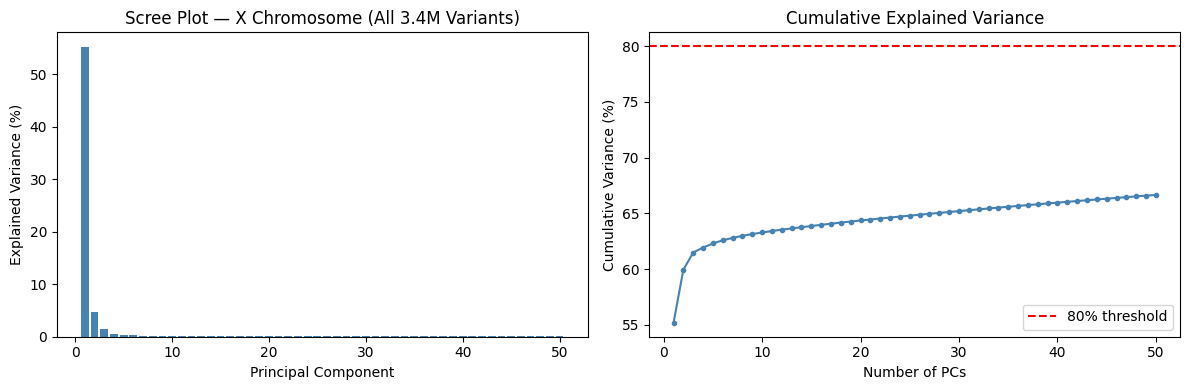

In [9]:
# ── Centre & eigendecompose the Gram matrix ───────────────────────────────
mu        = col_sum / col_count
n_var     = float(variants_used)
G_centred = G_cpu - n_var * np.outer(mu, mu)

print("Running eigendecomposition on Gram matrix (2504×2504)...")
t1 = time.time()

eigenvalues, eigenvectors = np.linalg.eigh(G_centred)
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]
eigenvalues  = eigenvalues[:N_COMPONENTS]
eigenvectors = eigenvectors[:, :N_COMPONENTS]

X_pca    = eigenvectors * np.sqrt(np.maximum(eigenvalues, 0))
total_var = np.linalg.eigvalsh(G_centred).sum()
explained = eigenvalues / total_var
cum_var   = np.cumsum(explained)

print(f"Eigendecomposition done in {time.time()-t1:.1f}s")
print(f"Variance explained by {N_COMPONENTS} PCs: {cum_var[-1]*100:.1f}%")
print(f"PC1: {explained[0]*100:.1f}%  |  PC2: {explained[1]*100:.1f}%")

# ── Scree + cumulative variance ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, N_COMPONENTS+1), explained*100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — X Chromosome (All 3.4M Variants)')

axes[1].plot(range(1, N_COMPONENTS+1), cum_var*100, marker='o', markersize=3, color='steelblue')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Load Sub-Population Labels (26 Classes)

Sub-population classes (26): ['ACB' 'ASW' 'BEB' 'CDX' 'CEU' 'CHB' 'CHS' 'CLM' 'ESN' 'FIN' 'GBR' 'GIH'
 'GWD' 'IBS' 'ITU' 'JPT' 'KHV' 'LWK' 'MSL' 'MXL' 'PEL' 'PJL' 'PUR' 'STU'
 'TSI' 'YRI']

Sub-population distribution:
GWD    113
YRI    108
IBS    107
TSI    107
CHS    105
PUR    104
JPT    104
CHB    103
GIH    103
STU    102
ITU    102
FIN     99
KHV     99
ESN     99
CEU     99
LWK     99
PJL     96
ACB     96
CLM     94
CDX     93
GBR     91
BEB     86
PEL     85
MSL     85
MXL     64
ASW     61


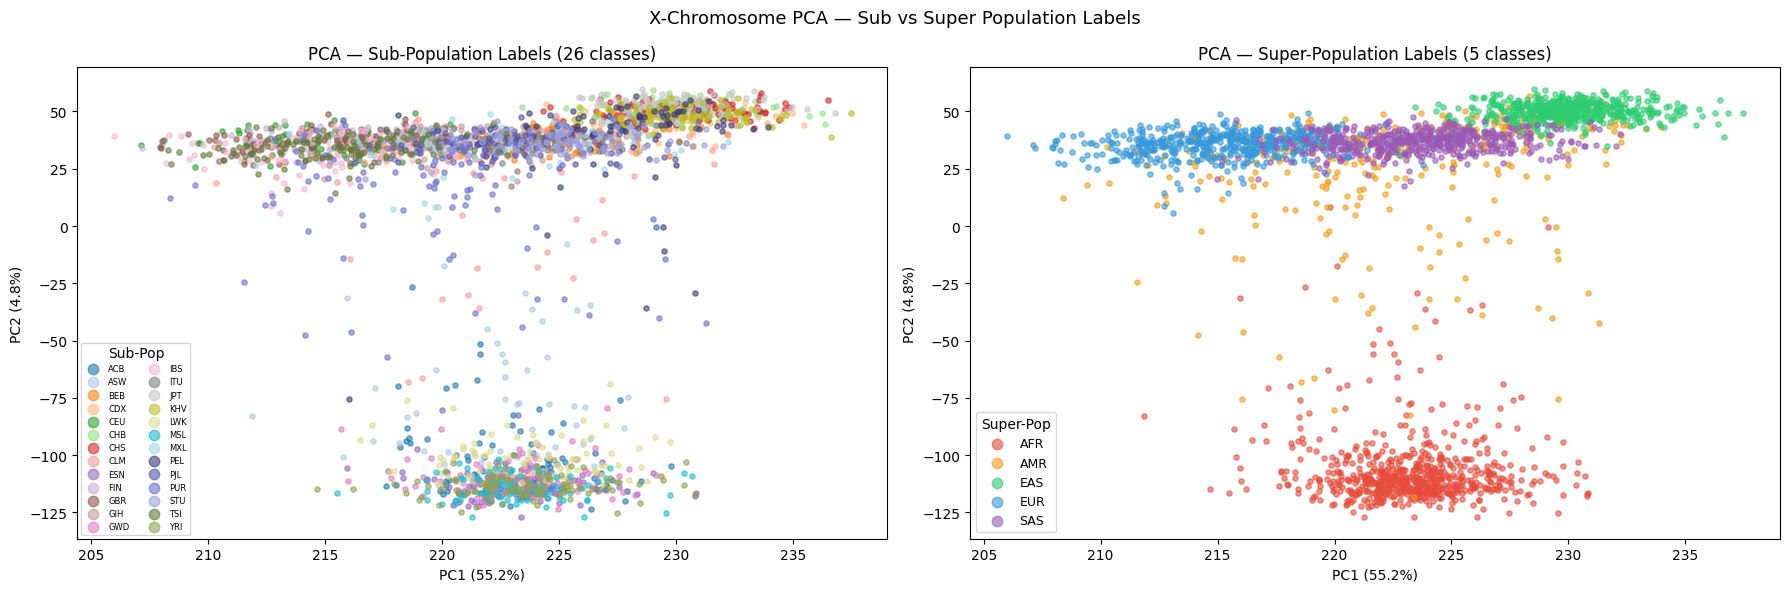

In [10]:
panel = panel_full[panel_full['sample'].isin(sample_arr)].set_index('sample').loc[sample_arr]

y_str     = panel['pop'].values        # 26 sub-populations
super_str = panel['super_pop'].values  # 5 super-pops (for colouring)
N_POPS    = len(np.unique(y_str))

le = LabelEncoder()
y  = le.fit_transform(y_str)

print(f"Sub-population classes ({N_POPS}): {le.classes_}")
print(f"\nSub-population distribution:")
print(pd.Series(y_str).value_counts().to_string())

# ── PCA scatter: sub-pop and super-pop side by side ───────────────────────
cmap26 = [plt.cm.tab20(i) for i in range(20)] + [plt.cm.tab20b(i) for i in range(6)]
pop_color_map = {pop: cmap26[i] for i, pop in enumerate(le.classes_)}
SUPER_COLORS  = {'AFR':'#E74C3C','AMR':'#F39C12','EAS':'#2ECC71','EUR':'#3498DB','SAS':'#9B59B6'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for pop in le.classes_:
    mask = y_str == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[pop_color_map[pop]], label=pop, alpha=0.6, s=14)
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("PCA — Sub-Population Labels (26 classes)")
axes[0].legend(title='Sub-Pop', markerscale=2, fontsize=6, ncol=2)

for spop in ['AFR','AMR','EAS','EUR','SAS']:
    mask = super_str == spop
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=SUPER_COLORS[spop], label=spop, alpha=0.6, s=14)
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title("PCA — Super-Population Labels (5 classes)")
axes[1].legend(title='Super-Pop', markerscale=2, fontsize=9)

plt.suptitle("X-Chromosome PCA — Sub vs Super Population Labels", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_pca_true_labels.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
X_train, X_test, y_train, y_test, y_train_str, y_test_str = train_test_split(
    X_pca, np.array(y), np.array(y_str), test_size=0.2, stratify=np.array(y), random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Classes: {N_POPS} sub-populations")

unique, counts = np.unique(y_train_str, return_counts=True)
print("\nTrain class distribution:")

for u, c in zip(unique, counts):
    print(f"  {u}: {c}")



Train: 2003 samples | Test: 501 samples
Classes: 26 sub-populations

Train class distribution:
  ACB: 77
  ASW: 49
  BEB: 69
  CDX: 75
  CEU: 79
  CHB: 82
  CHS: 84
  CLM: 75
  ESN: 79
  FIN: 79
  GBR: 73
  GIH: 82
  GWD: 90
  IBS: 86
  ITU: 82
  JPT: 83
  KHV: 79
  LWK: 79
  MSL: 68
  MXL: 51
  PEL: 68
  PJL: 77
  PUR: 83
  STU: 82
  TSI: 86
  YRI: 86


## 4. Supervised Classification (26 Sub-Population Classes)

In [14]:
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver='lbfgs', C=1.0, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale',
        decision_function_shape='ovo', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1),
}

results        = []
trained_models = {}

for name, clf in classifiers.items():
    print(f"\n{'─'*50}")
    print(f"Training: {name}")

    clf.fit(X_train, y_train)
    trained_models[name] = clf

    y_pred    = clf.predict(X_test)
    test_acc  = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results.append({
        'Model'        : name,
        'Test Accuracy': round(test_acc, 4),
        'CV Mean'      : round(cv_scores.mean(), 4),
        'CV Std'       : round(cv_scores.std(), 4),
    })
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


──────────────────────────────────────────────────
Training: Logistic Regression
  Test Accuracy : 0.4850
  CV Accuracy   : 0.4508 ± 0.0162
              precision    recall  f1-score   support

         ACB       0.27      0.32      0.29        19
         ASW       0.27      0.25      0.26        12
         BEB       0.30      0.41      0.35        17
         CDX       0.38      0.44      0.41        18
         CEU       0.50      0.30      0.38        20
         CHB       0.53      0.48      0.50        21
         CHS       0.24      0.19      0.21        21
         CLM       0.32      0.32      0.32        19
         ESN       0.59      0.50      0.54        20
         FIN       0.76      0.80      0.78        20
         GBR       0.33      0.22      0.27        18
         GIH       0.80      0.38      0.52        21
         GWD       0.65      0.65      0.65        23
         IBS       0.50      0.71      0.59        21
         ITU       0.24      0.25      0.24     


=== Model Comparison (26 Sub-Populations) ===
              Model  Test Accuracy  CV Mean  CV Std
          SVM (RBF)         0.5449   0.4967  0.0217
Logistic Regression         0.4850   0.4508  0.0162
      Random Forest         0.4651   0.4503  0.0160
          KNN (k=5)         0.3673   0.3719  0.0344
      Decision Tree         0.3353   0.3120  0.0103


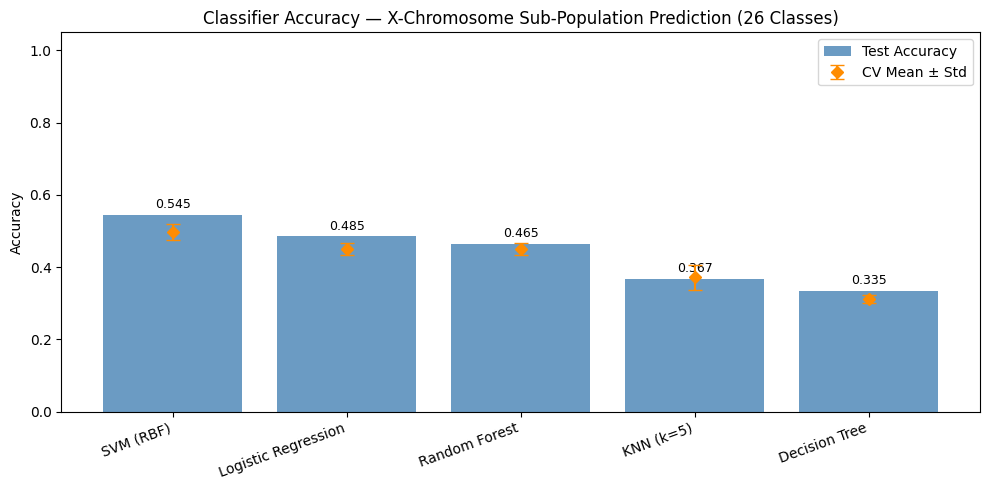

In [15]:
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n=== Model Comparison (26 Sub-Populations) ===")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x    = np.arange(len(results_df))
bars = ax.bar(x, results_df['Test Accuracy'], color='steelblue', alpha=0.8, label='Test Accuracy')
ax.errorbar(x, results_df['CV Mean'], yerr=results_df['CV Std'],
            fmt='D', color='darkorange', capsize=5, label='CV Mean ± Std', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Accuracy — X-Chromosome Sub-Population Prediction (26 Classes)')
ax.set_ylim(0, 1.05)
ax.legend()
for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_classifier_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

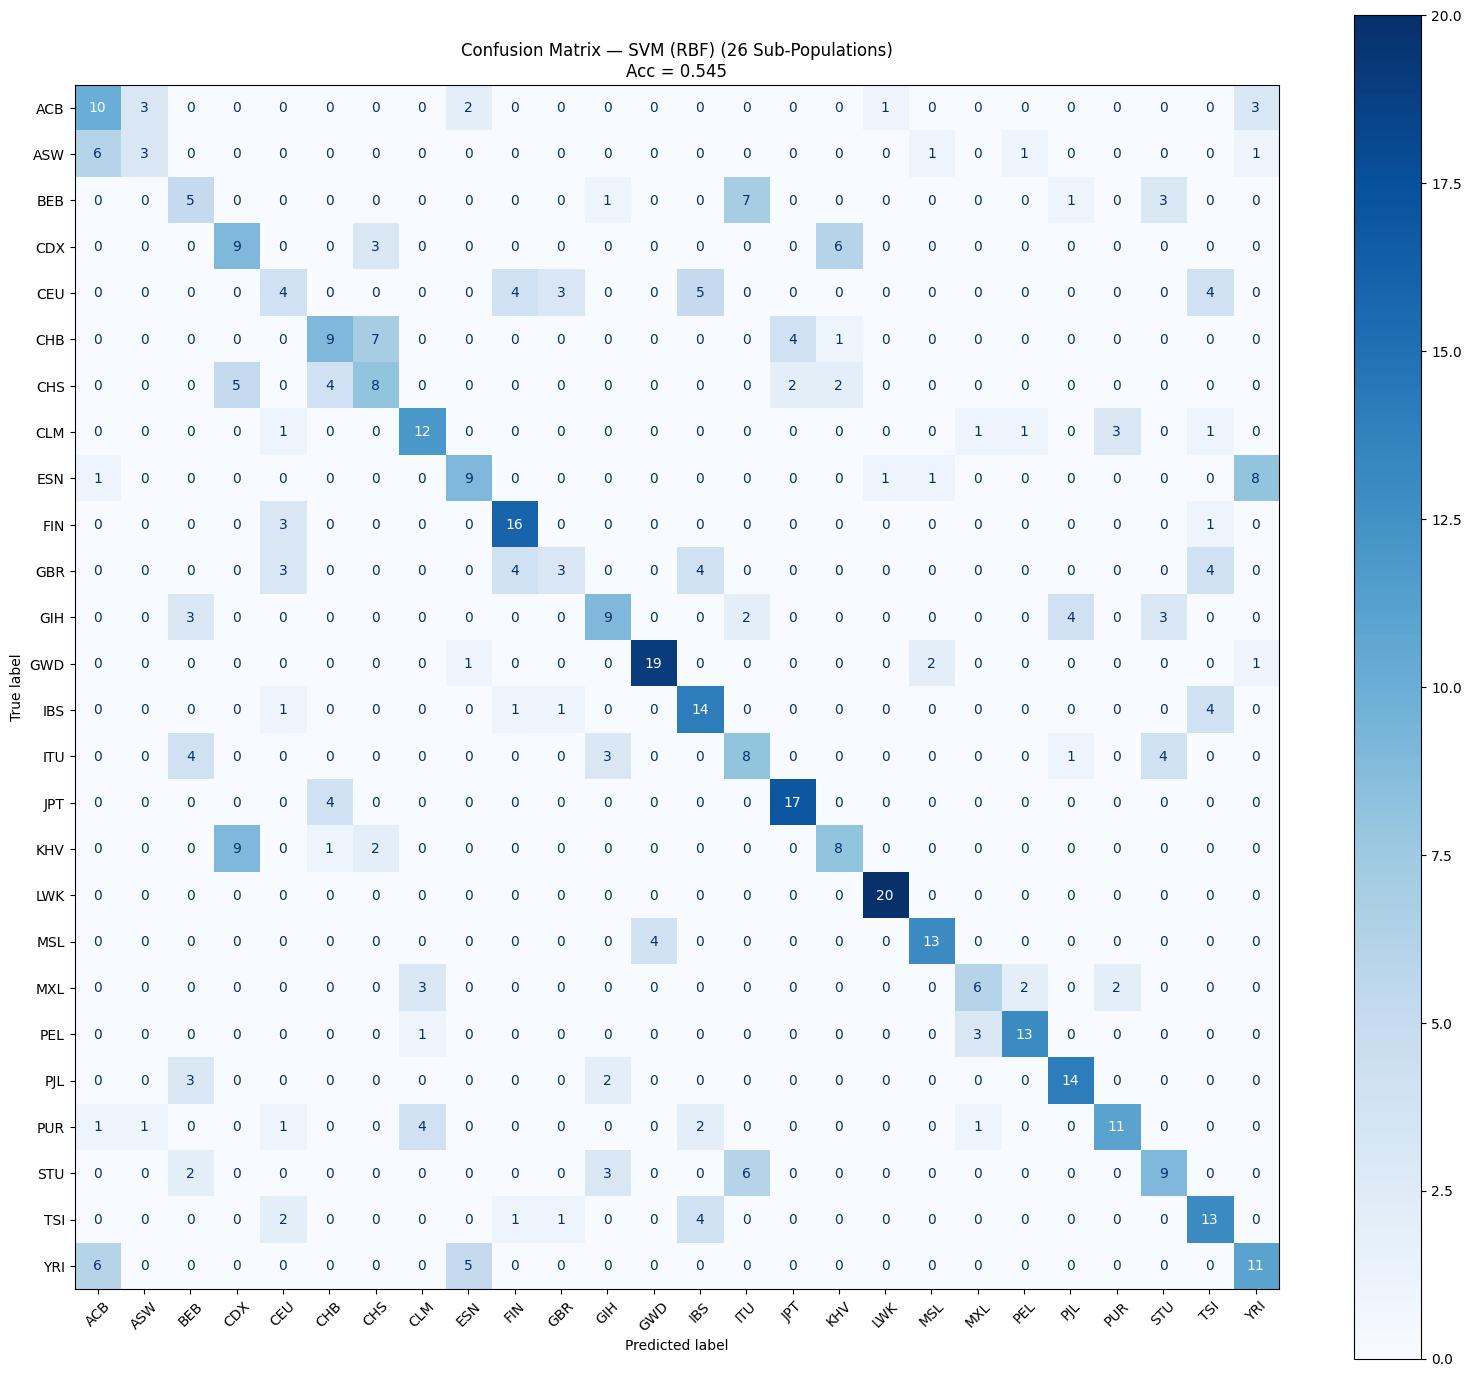


Best model: SVM (RBF)
              precision    recall  f1-score   support

         ACB       0.42      0.53      0.47        19
         ASW       0.43      0.25      0.32        12
         BEB       0.29      0.29      0.29        17
         CDX       0.39      0.50      0.44        18
         CEU       0.27      0.20      0.23        20
         CHB       0.50      0.43      0.46        21
         CHS       0.40      0.38      0.39        21
         CLM       0.60      0.63      0.62        19
         ESN       0.53      0.45      0.49        20
         FIN       0.62      0.80      0.70        20
         GBR       0.38      0.17      0.23        18
         GIH       0.50      0.43      0.46        21
         GWD       0.83      0.83      0.83        23
         IBS       0.48      0.67      0.56        21
         ITU       0.35      0.40      0.37        20
         JPT       0.74      0.81      0.77        21
         KHV       0.47      0.40      0.43        20
    

In [16]:
# Best model confusion matrix
best_name    = results_df.iloc[0]['Model']
best_clf     = trained_models[best_name]
y_pred_best  = best_clf.predict(X_test)

cm   = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {best_name} (26 Sub-Populations)\nAcc = {results_df.iloc[0]['Test Accuracy']:.3f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_confusion_matrix_best.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model: {best_name}")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

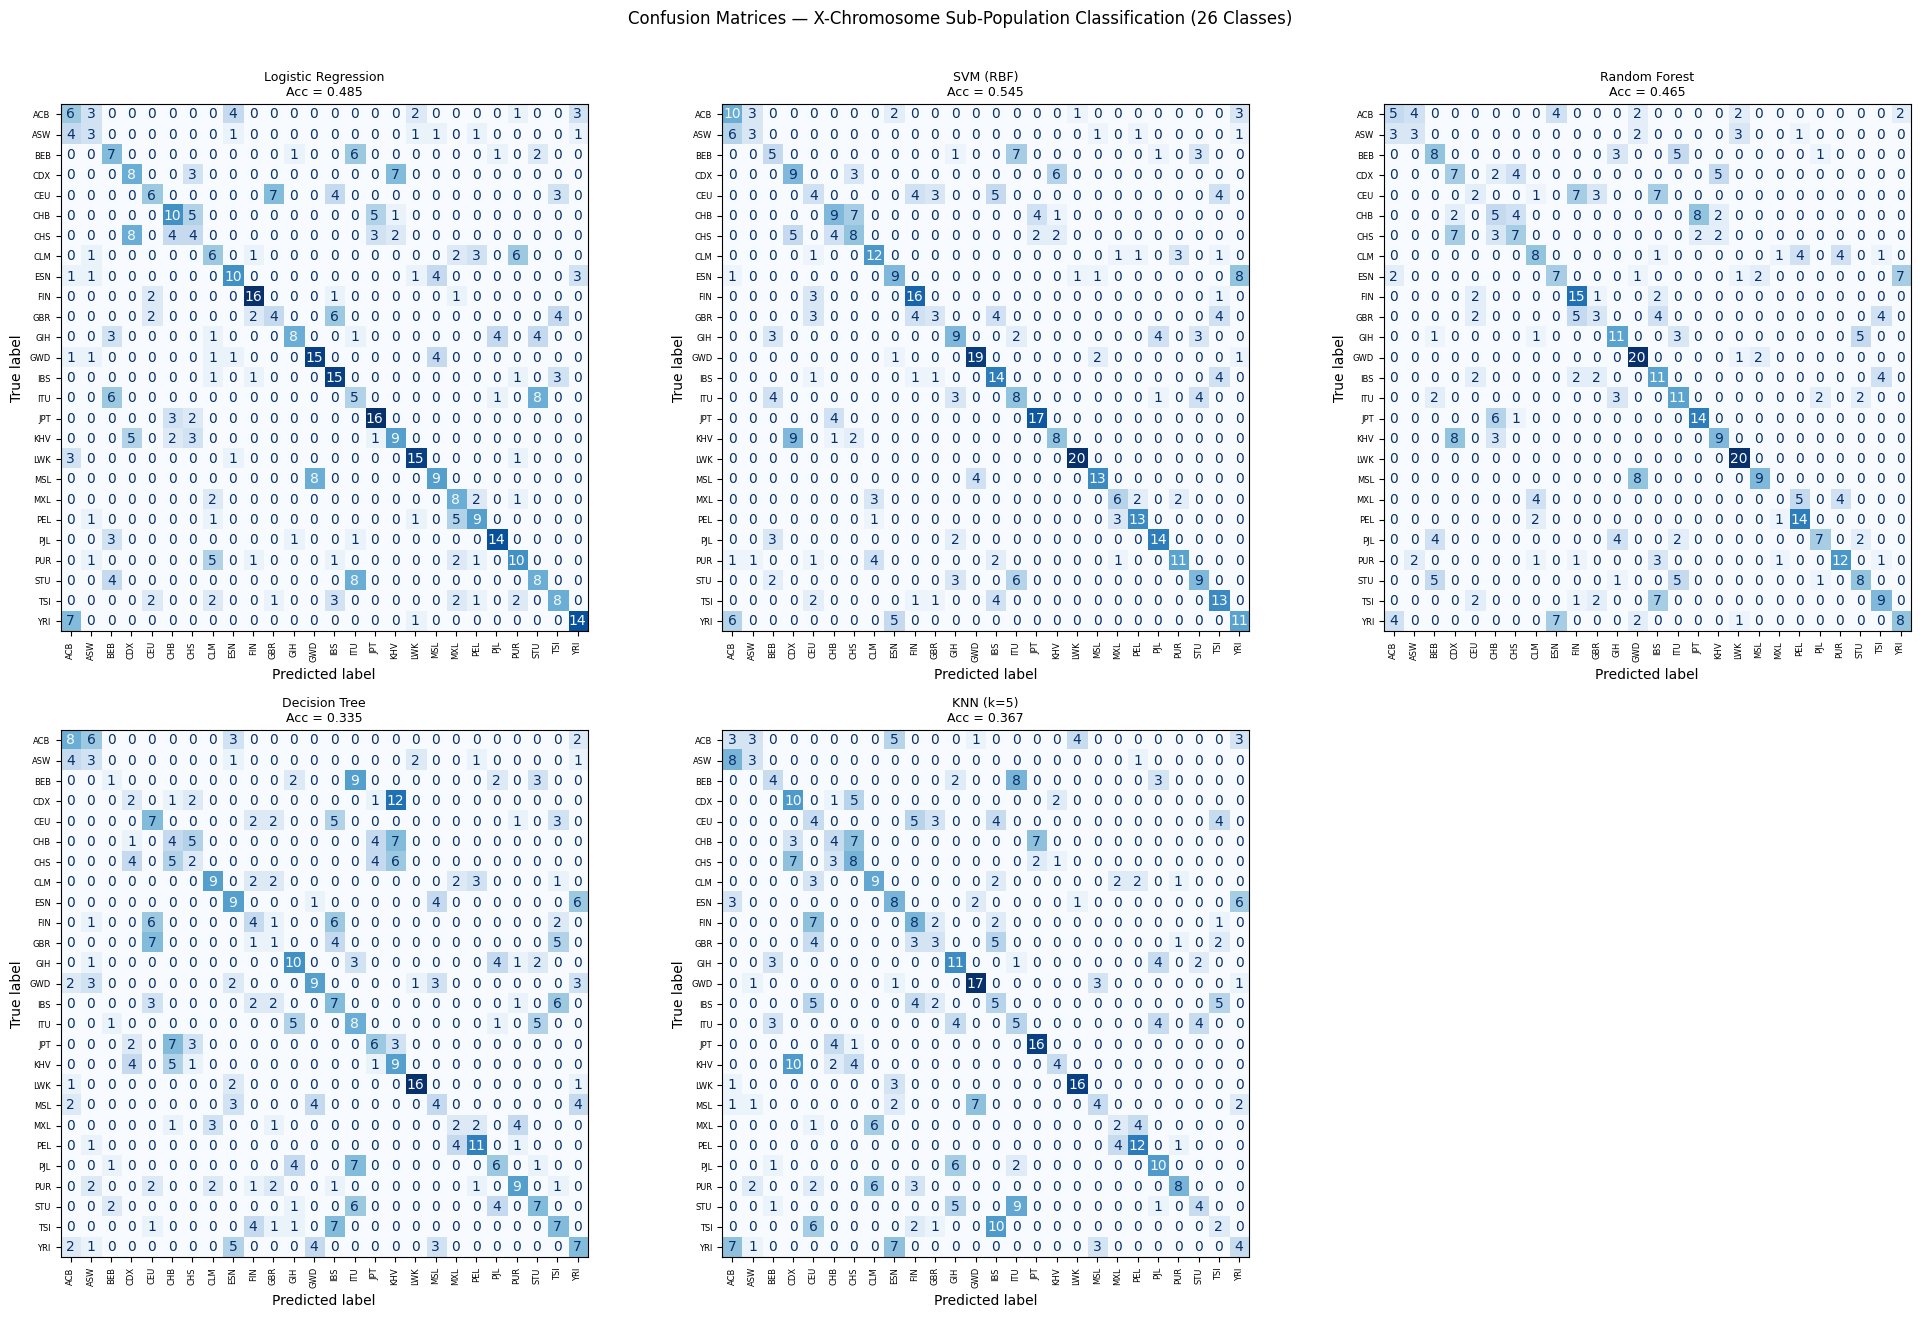

In [17]:
# All classifiers confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for idx, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues', xticks_rotation=90)
    axes[idx].set_title(f"{name}\nAcc = {accuracy_score(y_test, y_pred):.3f}", fontsize=9)
    axes[idx].tick_params(axis='both', labelsize=6)

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices — X-Chromosome Sub-Population Classification (26 Classes)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_confusion_matrices_all.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Unsupervised: K-Means Clustering (k=26)

In [18]:
kmeans         = KMeans(n_clusters=N_POPS, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)

print(f"K-Means (k={N_POPS}) Results")
print(f"  ARI : {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"  NMI : {nmi:.4f}  (1.0 = perfect, 0 = no shared info)")
print(f"  Inertia : {kmeans.inertia_:.2f}")

K-Means (k=26) Results
  ARI : 0.2077  (1.0 = perfect, 0 = random)
  NMI : 0.5163  (1.0 = perfect, 0 = no shared info)
  Inertia : 8869019.44


Clustering Accuracy (majority-vote mapping): 0.3211


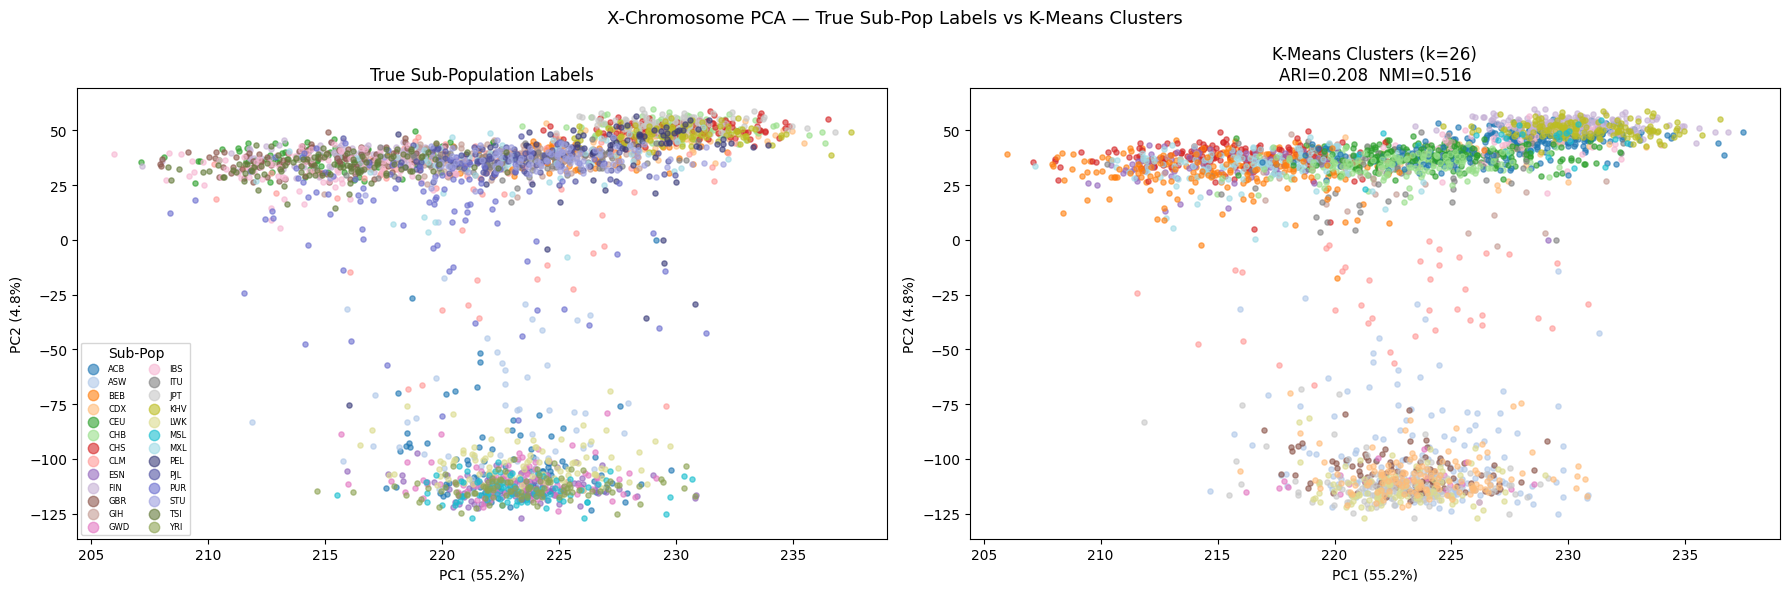

In [19]:
# Cluster → majority sub-pop mapping
composition_df = pd.DataFrame({'cluster': cluster_labels, 'true_pop': y_str})
cluster_to_pop = composition_df.groupby('cluster')['true_pop'].agg(lambda x: x.mode()[0])
predicted_pop  = composition_df['cluster'].map(cluster_to_pop)
cluster_acc    = (predicted_pop == composition_df['true_pop']).mean()
print(f"Clustering Accuracy (majority-vote mapping): {cluster_acc:.4f}")

comp_table = composition_df.groupby(['cluster','true_pop']).size().unstack(fill_value=0)
comp_pct   = comp_table.div(comp_table.sum(axis=1), axis=0).round(3)

# Side-by-side scatter
cluster_colors = [plt.cm.tab20(i % 20) for i in range(N_POPS)]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for pop in le.classes_:
    mask = y_str == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[pop_color_map[pop]], label=pop, alpha=0.6, s=14)
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("True Sub-Population Labels")
axes[0].legend(title='Sub-Pop', markerscale=2, fontsize=6, ncol=2)

for k in range(N_POPS):
    mask = cluster_labels == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=cluster_colors[k], label=f"C{k}", alpha=0.6, s=14)
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title(f"K-Means Clusters (k={N_POPS})\nARI={ari:.3f}  NMI={nmi:.3f}")

plt.suptitle("X-Chromosome PCA — True Sub-Pop Labels vs K-Means Clusters", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_kmeans_vs_true.png", dpi=150, bbox_inches='tight')
plt.show()

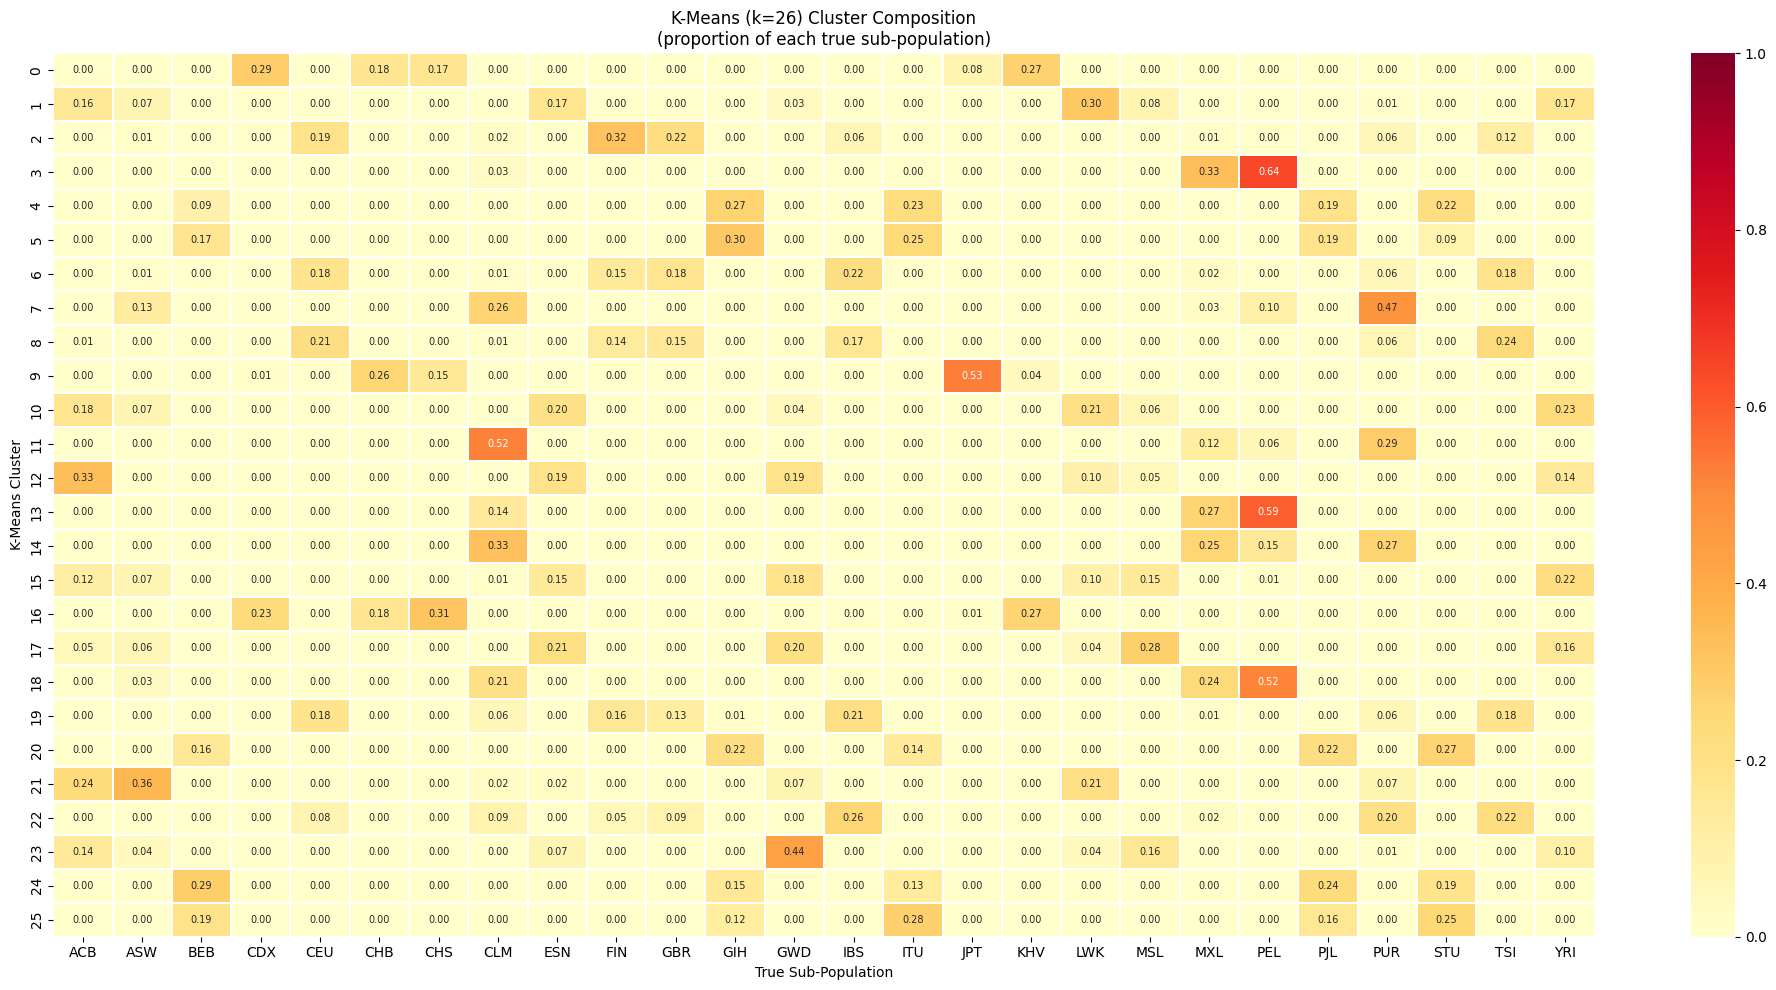


Cluster size distribution:
0     195
1     154
2     127
3      36
4     127
5      69
6     142
7      38
8      79
9     162
10     95
11     48
12     21
13     49
14     67
15    122
16    147
17    100
18     29
19    133
20     83
21     42
22    104
23    126
24     97
25    112


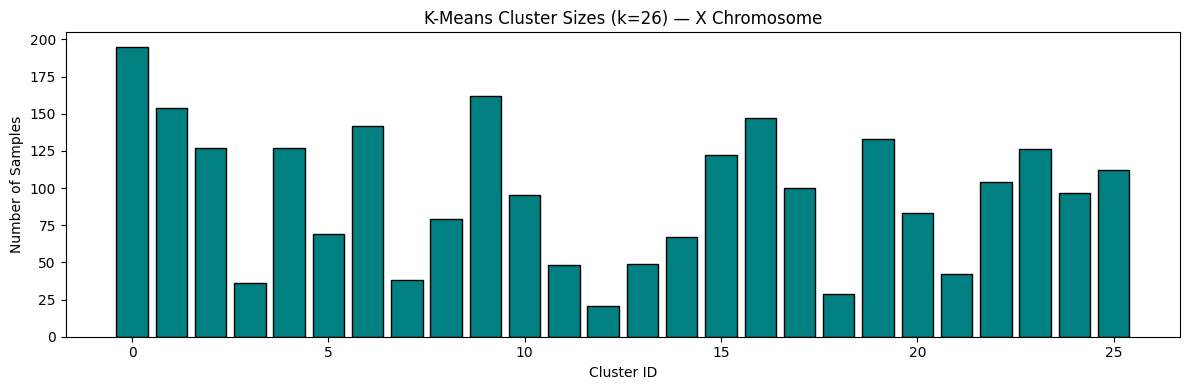

In [20]:
# Cluster composition heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(comp_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.3, vmin=0, vmax=1, annot_kws={'size': 7})
plt.title(f"K-Means (k={N_POPS}) Cluster Composition\n(proportion of each true sub-population)")
plt.xlabel("True Sub-Population")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_kmeans_composition_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# Cluster sizes
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster size distribution:")
print(cluster_sizes.to_string())

plt.figure(figsize=(12, 4))
plt.bar(cluster_sizes.index, cluster_sizes.values, color='teal', edgecolor='black')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Samples')
plt.title(f'K-Means Cluster Sizes (k={N_POPS}) — X Chromosome')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_kmeans_cluster_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

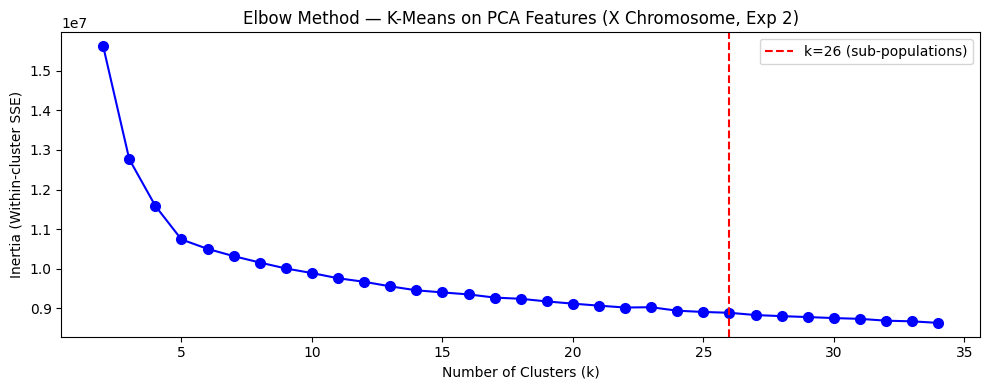

In [21]:
# Elbow method
inertias = []
k_range  = range(2, 35)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(list(k_range), inertias, 'bo-', markersize=7)
plt.axvline(x=26, color='red', linestyle='--', label='k=26 (sub-populations)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method — K-Means on PCA Features (X Chromosome, Exp 2)')
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_kmeans_elbow.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Final Summary

In [22]:
best = results_df.iloc[0]

print("=" * 60)
print("EXPERIMENT 2 — X CHROMOSOME FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset : {X_pca.shape[0]:,} samples | 3,449,249 variants | 50 PCs")
print(f"Target  : {N_POPS} sub-populations — {list(le.classes_)}")

print("\n── SUPERVISED (Test Accuracy) ──")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} {row['Test Accuracy']:.4f}  "
          f"(CV: {row['CV Mean']:.4f} ± {row['CV Std']:.4f})")
print(f"\n  Best model: {best['Model']} (Test Acc = {best['Test Accuracy']:.4f})")

print("\n── UNSUPERVISED (K-Means, k=26) ──")
print(f"  ARI                      : {ari:.4f}")
print(f"  NMI                      : {nmi:.4f}")
print(f"  Clustering Accuracy      : {cluster_acc:.4f}")

print("\n── COMPARISON WITH EXP 1 (5 super-pops) ──")
print(f"  Exp 1 best accuracy (SVM): 0.9860")
print(f"  Exp 2 best accuracy      : {best['Test Accuracy']:.4f}")
print(f"  Exp 1 K-Means ARI        : 0.8898")
print(f"  Exp 2 K-Means ARI        : {ari:.4f}")

print("\nAll plots saved to Output/ directory.")
print("=" * 60)

EXPERIMENT 2 — X CHROMOSOME FINAL SUMMARY

Dataset : 2,504 samples | 3,449,249 variants | 50 PCs
Target  : 26 sub-populations — ['ACB', 'ASW', 'BEB', 'CDX', 'CEU', 'CHB', 'CHS', 'CLM', 'ESN', 'FIN', 'GBR', 'GIH', 'GWD', 'IBS', 'ITU', 'JPT', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL', 'PUR', 'STU', 'TSI', 'YRI']

── SUPERVISED (Test Accuracy) ──
  SVM (RBF)              0.5449  (CV: 0.4967 ± 0.0217)
  Logistic Regression    0.4850  (CV: 0.4508 ± 0.0162)
  Random Forest          0.4651  (CV: 0.4503 ± 0.0160)
  KNN (k=5)              0.3673  (CV: 0.3719 ± 0.0344)
  Decision Tree          0.3353  (CV: 0.3120 ± 0.0103)

  Best model: SVM (RBF) (Test Acc = 0.5449)

── UNSUPERVISED (K-Means, k=26) ──
  ARI                      : 0.2077
  NMI                      : 0.5163
  Clustering Accuracy      : 0.3211

── COMPARISON WITH EXP 1 (5 super-pops) ──
  Exp 1 best accuracy (SVM): 0.9860
  Exp 2 best accuracy      : 0.5449
  Exp 1 K-Means ARI        : 0.8898
  Exp 2 K-Means ARI        : 0.2077

Al